In [1]:
import pandas as pd

df = pd.read_csv('e_commerce_store.csv')

In [2]:
df.head()

,Date,Region,Brand,Product,Product Type,Sales,Profit,Units Sold,Discount (%),Customer Rating
0,4/11/2023,South,Brand C,Product 2,Home Appliances,4574.16,1642.07,152,19.76,3.40
1,4/27/2023,West,Brand A,Product 3,Consumer Goods,12631.78,4172.09,398,17.93,4.48
2,4/8/2023,East,Brand A,Product 5,Electronics,9884.40,3448.69,320,11.71,4.65
3,2/5/2023,West,Brand B,Product 1,Electronics,5344.99,1926.96,156,21.74,3.01
4,8/9/2023,West,Brand A,Product 2,Electronics,4890.45,1682.51,121,14.40,3.57


In [3]:
df.describe()

,Sales,Profit,Units Sold,Discount (%),Customer Rating
count,698.000000,698.000000,698.000000,698.000000,698.000000
mean,7358.320559,2488.094527,226.717765,12.757794,3.663438
std,3094.972508,1004.723565,98.300869,6.818527,0.651065
min,1254.220000,401.080000,50.000000,1.010000,1.860000
25%,4966.182500,1717.845000,148.000000,6.580000,3.212500
50%,7355.240000,2458.860000,225.000000,12.910000,3.650000
75%,9862.620000,3289.300000,307.000000,18.790000,4.150000
max,13641.030000,4455.560000,399.000000,24.890000,5.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             698 non-null    object 
 1   Region           698 non-null    object 
 2   Brand            698 non-null    object 
 3   Product          698 non-null    object 
 4   Product Type     698 non-null    object 
 5   Sales            698 non-null    float64
 6   Profit           698 non-null    float64
 7   Units Sold       698 non-null    int64  
 8   Discount (%)     698 non-null    float64
 9   Customer Rating  698 non-null    float64
dtypes: float64(4), int64(1), object(5)
memory usage: 54.7+ KB


In [5]:
df.shape

(698, 10)

The dataset has **698 rows** (sales records) and **10 columns**: 4 categorical (Region, Brand, Product, Product Type), 1 date (Date) and 5 numerical (Sales, Profit, Units Sold, Discount (%), Customer Rating).

# EDA 

# Basic Diagnosis

In [6]:
data = df [['Sales', 'Profit', 'Units Sold', 'Discount (%)', 'Customer Rating']]

In [7]:
data.head()

,Sales,Profit,Units Sold,Discount (%),Customer Rating
0,4574.16,1642.07,152,19.76,3.40
1,12631.78,4172.09,398,17.93,4.48
2,9884.40,3448.69,320,11.71,4.65
3,5344.99,1926.96,156,21.74,3.01
4,4890.45,1682.51,121,14.40,3.57


In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
print(df['Date'].min(), df['Date'].max())

2023-01-01 00:00:00 2023-12-31 00:00:00


In [9]:
df.isna().sum()

Date               0
Region             0
Brand              0
Product            0
Product Type       0
Sales              0
Profit             0
Units Sold         0
Discount (%)       0
Customer Rating    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

No missing values and no duplicates, so no cleaning is needed. Date was text, so it was converted to a date – the data covers the whole year 2023 (1 Jan – 31 Dec).

# Descriptive 

In [11]:
data.describe()

,Sales,Profit,Units Sold,Discount (%),Customer Rating
count,698.000000,698.000000,698.000000,698.000000,698.000000
mean,7358.320559,2488.094527,226.717765,12.757794,3.663438
std,3094.972508,1004.723565,98.300869,6.818527,0.651065
min,1254.220000,401.080000,50.000000,1.010000,1.860000
25%,4966.182500,1717.845000,148.000000,6.580000,3.212500
50%,7355.240000,2458.860000,225.000000,12.910000,3.650000
75%,9862.620000,3289.300000,307.000000,18.790000,4.150000
max,13641.030000,4455.560000,399.000000,24.890000,5.000000


# Mean

In [12]:
data.mean()

Sales              7358.320559
Profit             2488.094527
Units Sold          226.717765
Discount (%)         12.757794
Customer Rating       3.663438
dtype: float64

In [13]:
data.std()

Sales              3094.972508
Profit             1004.723565
Units Sold           98.300869
Discount (%)          6.818527
Customer Rating       0.651065
dtype: float64

In [14]:
data.var()

Sales              9.578855e+06
Profit             1.009469e+06
Units Sold         9.663061e+03
Discount (%)       4.649231e+01
Customer Rating    4.238857e-01
dtype: float64

In [15]:
data.skew()

Sales             -0.024816
Profit            -0.005703
Units Sold        -0.016451
Discount (%)       0.034321
Customer Rating   -0.100025
dtype: float64

- Average sale is 7,358 and average profit is 2,488. On average 227 units are sold, with a 12.8% discount and a 3.66 rating.
- Skewness is close to 0 for all variables, so the distributions are symmetric.

In [16]:
import plotly.express as px

for col in data.columns:
    px.histogram(df, x=col, nbins=30, title=f'Distribution of {col}').show()

Sales, Profit, Units Sold and Discount are spread widely over their range, without one clear peak. Customer Rating has a bell shape with most values around 3.5–4.

In [17]:
for col in data.columns:
    px.box(df, y=col, title=f'Box Plot of {col}').show()

The box plots show **no outliers** – all values are inside the whiskers.

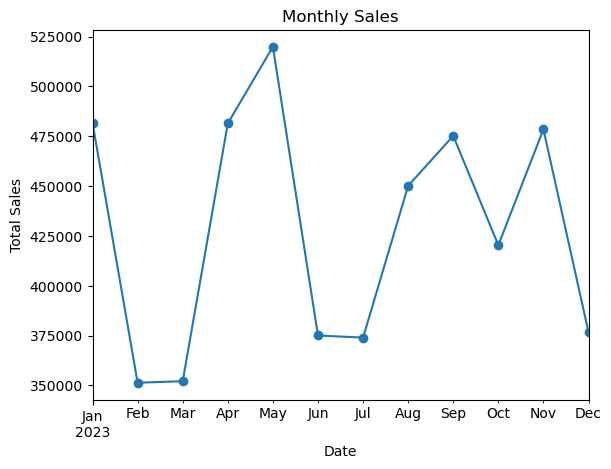

In [18]:
monthly = df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum()
monthly.plot(kind='line', marker='o', title='Monthly Sales', ylabel='Total Sales');

Total sales change from month to month. The highest month is May, the lowest are February and March. There is no clear trend over the year.

#  Visuslization

In [19]:
df.head()

,Date,Region,Brand,Product,Product Type,Sales,Profit,Units Sold,Discount (%),Customer Rating
0,2023-04-11,South,Brand C,Product 2,Home Appliances,4574.16,1642.07,152,19.76,3.40
1,2023-04-27,West,Brand A,Product 3,Consumer Goods,12631.78,4172.09,398,17.93,4.48
2,2023-04-08,East,Brand A,Product 5,Electronics,9884.40,3448.69,320,11.71,4.65
3,2023-02-05,West,Brand B,Product 1,Electronics,5344.99,1926.96,156,21.74,3.01
4,2023-08-09,West,Brand A,Product 2,Electronics,4890.45,1682.51,121,14.40,3.57


In [20]:
df['Brand'].value_counts()

Brand
Brand A    184
Brand C    180
Brand B    173
Brand D    161
Name: count, dtype: int64

In [21]:
import plotly.express as px


brand_counts = df['Brand'].value_counts().reset_index()
brand_counts.columns = ['Brand', 'Count']  # Rename columns for clarity

# Create a bar chart
fig_brand_counts = px.bar(brand_counts, 
                          x='Brand', y='Count',
                          labels={'Brand': 'Brand', 'Count': 'Frequency'},
                          title='Frequency of Each Brand',
                          color='Brand',
                          text='Count',  # Add labels above the bars
                          height=600,  # Resize height
                          width=1000)  # Resize width
fig_brand_counts.update_traces(textposition='outside')  # Position the labels outside the bars
fig_brand_counts.show()

# Can you do it for the others?

In [22]:
for col in ['Region', 'Brand', 'Product', 'Product Type']:
    t = pd.DataFrame({
        'Count': df[col].value_counts(),
        'Percent': df[col].value_counts(normalize=True).mul(100).round(1)
    })
    print(f'\n{col}\n', t)


Region
         Count  Percent
Region                
West      187     26.8
East      184     26.4
South     174     24.9
North     153     21.9

Brand
          Count  Percent
Brand                  
Brand A    184     26.4
Brand C    180     25.8
Brand B    173     24.8
Brand D    161     23.1

Product
            Count  Percent
Product                  
Product 2    173     24.8
Product 1    140     20.1
Product 5    133     19.1
Product 3    126     18.1
Product 4    126     18.1

Product Type
                  Count  Percent
Product Type                   
Consumer Goods     179     25.6
Electronics        178     25.5
Apparel            176     25.2
Home Appliances    165     23.6


All categories have a similar share of records:
- Region: West 26.8%, East 26.4%, South 24.9%, North 21.9%.
- Brand: from 23.1% (Brand D) to 26.4% (Brand A).
- Product: Product 2 is the most common (24.8%), the others are 18–20%.
- Product Type: almost equal, 23.6–25.6%.

The bar charts below show the same.

In [23]:
region_counts = df['Region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Count']

fig_region_counts = px.bar(region_counts,
                          x='Region', y='Count',
                          labels={'Region': 'Region', 'Count': 'Frequency'},
                          title='Frequency of Each Region',
                          color='Region',
                          text='Count',
                          height=600,
                          width=1000)
fig_region_counts.update_traces(textposition='outside')
fig_region_counts.show()

In [24]:
product_counts = df['Product'].value_counts().reset_index()
product_counts.columns = ['Product', 'Count']

fig_product_counts = px.bar(product_counts,
                          x='Product', y='Count',
                          labels={'Product': 'Product', 'Count': 'Frequency'},
                          title='Frequency of Each Product',
                          color='Product',
                          text='Count',
                          height=600,
                          width=1000)
fig_product_counts.update_traces(textposition='outside')
fig_product_counts.show()

In [25]:
product_type_counts = df['Product Type'].value_counts().reset_index()
product_type_counts.columns = ['Product Type', 'Count']

fig_product_type_counts = px.bar(product_type_counts,
                          x='Product Type', y='Count',
                          labels={'Product Type': 'Product Type', 'Count': 'Frequency'},
                          title='Frequency of Each Product Type',
                          color='Product Type',
                          text='Count',
                          height=600,
                          width=1000)
fig_product_type_counts.update_traces(textposition='outside')
fig_product_type_counts.show()

In [26]:
pd.crosstab(df['Region'], df['Product Type'], normalize='index').round(3) * 100

Product Type,Apparel,Consumer Goods,Electronics,Home Appliances
Region,,,,
East,28.8,23.9,20.1,27.2
North,24.2,29.4,22.9,23.5
South,27.0,25.3,27.0,20.7
West,20.9,24.6,31.6,23.0


Share of product types in each region (row = 100%). There are some differences, e.g. Electronics is 31.6% in West but 20.1% in East. The chi-square test at the end checks if this is significant.

# Sales and its Visulization 

# A. Sales by Region

In [27]:
import plotly.express as px

region_sales = df.groupby('Region')['Sales'].sum().reset_index()

# Create a bar chart for sales by region
fig_region = px.bar(region_sales, 
                    x='Region', y='Sales',
                    labels={'Region': 'Region', 'Sales': 'Total Sales'},
                    title='Total Sales by Region',
                    color='Region',
                    text='Sales',  # Add labels above the bars
                    height=600,  # Resize height
                    width=700)  # Resize width
fig_region.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_region.show()

# B. Sales by Brand

In [28]:
# Group by 'Brand' and calculate total sales
brand_sales = df.groupby('Brand')['Sales'].sum().reset_index()

# Create a bar chart for sales by brand
fig_brand = px.bar(brand_sales, 
                   x='Brand', y='Sales',
                   labels={'Brand': 'Brand', 'Sales': 'Total Sales'},
                   title='Total Sales by Brand',
                   color='Brand',
                   text='Sales',  # Add labels above the bars
                   height=400,  # Resize height
                   width=700)  # Resize width
fig_brand.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_brand.show()


# C. Sales by product

In [29]:
# Group by 'Product' and calculate total sales
product_sales = df.groupby('Product')['Sales'].sum().reset_index()

# Create a bar chart for sales by product
fig_product = px.bar(product_sales, 
                     x='Product', y='Sales',
                     labels={'Product': 'Product', 'Sales': 'Total Sales'},
                     title='Total Sales by Product',
                     color='Product',
                     text='Sales',  # Add labels above the bars
                     height=400,  # Resize height
                     width=700)  # Resize width
fig_product.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_product.show()


# D. Sales by Product Type

In [30]:
# Group by 'Product' and calculate total sales
product_sales = df.groupby('Product Type')['Sales'].sum().reset_index()

# Create a bar chart for sales by product
fig_product = px.bar(product_sales, 
                     x='Product Type', y='Sales',
                     labels={'Product': 'Product Type', 'Sales': 'Total Sales'},
                     title='Total Sales by Product Type',
                     color='Product Type',
                     text='Sales',  # Add labels above the bars
                     height=400,  # Resize height
                     width=700)  # Resize width
fig_product.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_product.show()


**Total sales:** West and East have the highest sales, North the lowest. Brand A and Product 2 are the best. Product types are almost equal. These totals mostly follow the number of records – groups with more records (see the frequency tables) usually have higher totals.

# Please do it by your self for Profits 

In [31]:
# Group by 'Product' and calculate total sales
product_sales = df.groupby('Product Type')['Profit'].sum().reset_index()

# Create a bar chart for sales by product
fig_product = px.bar(product_sales, 
                     x='Product Type', y='Profit',
                     labels={'Product': 'Product Type', 'Profit': 'Total Profit'},
                     title='Total Profit by Product Type',
                     color='Product Type',
                     text='Profit',  # Add labels above the bars
                     height=400,  # Resize height
                     width=700)  # Resize width
fig_product.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_product.show()


In [32]:
df.columns

Index(['Date', 'Region', 'Brand', 'Product', 'Product Type', 'Sales', 'Profit',
       'Units Sold', 'Discount (%)', 'Customer Rating'],
      dtype='object')

In [33]:
# Group by 'Product' and calculate total sales
product_sales = df.groupby('Brand')['Profit'].sum().reset_index()

# Create a bar chart for sales by product
fig_product = px.bar(product_sales, 
                     x='Brand', y='Profit',
                     labels={'Brand': 'Brand', 'Profit': 'Total Profit'},
                     title='Total Profit by Brand',
                     color='Brand',
                     text='Profit',  # Add labels above the bars
                     height=400,  # Resize height
                     width=700)  # Resize width
fig_product.update_traces(texttemplate='%{text:.2s}', textposition='outside')  # Shortened text format
fig_product.show()


In [34]:
region_profit = df.groupby('Region')['Profit'].sum().reset_index()

fig_region_profit = px.bar(region_profit,
                          x='Region', y='Profit',
                          labels={'Region': 'Region', 'Profit': 'Total Profit'},
                          title='Total Profit by Region',
                          color='Region',
                          text='Profit',
                          height=400,
                          width=700)
fig_region_profit.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig_region_profit.show()

In [35]:
product_profit = df.groupby('Product')['Profit'].sum().reset_index()

fig_product_profit = px.bar(product_profit,
                          x='Product', y='Profit',
                          labels={'Product': 'Product', 'Profit': 'Total Profit'},
                          title='Total Profit by Product',
                          color='Product',
                          text='Profit',
                          height=400,
                          width=700)
fig_product_profit.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig_product_profit.show()

In [36]:
df['Margin (%)'] = df['Profit'] / df['Sales'] * 100

for col in ['Region', 'Brand', 'Product', 'Product Type']:
    print(f'\n{col}\n', df.groupby(col)[['Sales', 'Profit', 'Margin (%)']].mean().round(2))


Region
           Sales   Profit  Margin (%)
Region                              
East    7358.87  2489.04       34.22
North   7438.54  2500.83       34.03
South   7202.25  2436.89       34.41
West    7437.37  2524.39       34.61

Brand
            Sales   Profit  Margin (%)
Brand                                
Brand A  7464.44  2537.45       34.77
Brand B  7321.70  2448.89       33.75
Brand C  7392.11  2501.89       34.39
Brand D  7238.61  2458.38       34.39

Product
              Sales   Profit  Margin (%)
Product                                
Product 1  7433.74  2506.63       34.30
Product 2  7535.33  2542.06       34.20
Product 3  7293.27  2470.37       34.45
Product 4  7152.74  2423.84       34.40
Product 5  7305.07  2476.05       34.36

Product Type
                    Sales   Profit  Margin (%)
Product Type                                 
Apparel          7191.48  2440.72       34.63
Consumer Goods   7246.71  2455.62       34.34
Electronics      7423.72  2516.57       34.4

**Total profit** shows the same ranking as total sales. But the **averages are very similar** in all groups (average profit 2,424–2,543) and the **profit margin is about 34% everywhere** (33.75–34.77%). For example, Home Appliances has the lowest total profit but the highest average profit (2,543) – it just has fewer records.

So no region, brand, product or product type is really more profitable per sale. The differences in totals come mainly from the number of sales.

# Some More Advanced Vislizations 

In [37]:
df.head()

,Date,Region,Brand,Product,Product Type,Sales,Profit,Units Sold,Discount (%),Customer Rating,Margin (%)
0,2023-04-11,South,Brand C,Product 2,Home Appliances,4574.16,1642.07,152,19.76,3.40,35.898832
1,2023-04-27,West,Brand A,Product 3,Consumer Goods,12631.78,4172.09,398,17.93,4.48,33.028520
2,2023-04-08,East,Brand A,Product 5,Electronics,9884.40,3448.69,320,11.71,4.65,34.890231
3,2023-02-05,West,Brand B,Product 1,Electronics,5344.99,1926.96,156,21.74,3.01,36.051704
4,2023-08-09,West,Brand A,Product 2,Electronics,4890.45,1682.51,121,14.40,3.57,34.403991


In [38]:
px.imshow(data.corr().round(2), text_auto=True, title='Correlation Matrix')

- Sales, Profit and Units Sold are almost perfectly correlated (0.99).
- Customer Rating has a strong positive correlation with them (0.76–0.78).
- Discount has almost no correlation with anything (−0.05 to 0.01).

In [39]:
for x, y in [('Sales', 'Profit'), ('Units Sold', 'Sales'), ('Discount (%)', 'Profit'), ('Customer Rating', 'Sales')]:
    px.scatter(df, x=x, y=y, trendline='ols', title=f'{y} vs {x}').show()

The scatter plots confirm this: Profit grows with Sales and Sales grow with Units Sold in an almost straight line. Higher ratings come with higher sales. The Discount line is flat – a bigger discount does not change profit.

In [40]:
for col in ['Region', 'Brand', 'Product', 'Product Type']:
    px.box(df, x=col, y='Profit', title=f'Profit by {col}').show()

In [41]:
from scipy.stats import f_oneway, chi2_contingency

for col in ['Region', 'Brand', 'Product', 'Product Type']:
    print(col, f_oneway(*[g['Profit'] for _, g in df.groupby(col)]))

Region F_onewayResult(statistic=np.float64(0.2394430181600452), pvalue=np.float64(0.8688502058117039))
Brand F_onewayResult(statistic=np.float64(0.29317153230571075), pvalue=np.float64(0.8303500714298788))
Product F_onewayResult(statistic=np.float64(0.2789529419097598), pvalue=np.float64(0.8916420434929697))
Product Type F_onewayResult(statistic=np.float64(0.40442454527974964), pvalue=np.float64(0.7498672430168057))


The box plots of Profit look almost the same in all groups. ANOVA confirms it: p-value is 0.75–0.89 for all four variables (> 0.05), so **average profit does not differ significantly** between regions, brands, products or product types.

In [42]:
chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['Region'], df['Product Type']))
print(f'Chi-square: {chi2:.4f}, p-value: {p:.4f}, dof: {dof}')

Chi-square: 10.7846, p-value: 0.2908, dof: 9


Chi-square: p-value = 0.29 > 0.05, so the product type mix **does not depend** on the region. The differences in the crosstab are not significant.

# Overall Findings

- The data is clean: 698 records, 10 variables, no missing values, no duplicates, no outliers, the whole year 2023.
- All categories (regions, brands, products, product types) have a similar number of records. Product 2 is the most common product.
- Sales, Profit, Units Sold and Discount are spread widely over their range, without one clear peak. Customer Rating is bell-shaped around 3.5–4.
- Profit is driven by sales volume: Sales, Profit and Units Sold are almost perfectly correlated (0.99), and the profit margin is about 34% in every group.
- Higher customer ratings come with higher sales (correlation 0.78).
- Discount has no link with sales or profit (correlation close to 0), so bigger discounts do not bring more profit.
- Groups differ in total sales and profit mainly because of the number of records. Average profit is not significantly different (ANOVA p > 0.05) and the product mix does not depend on the region (chi-square p = 0.29).
- Monthly sales go up and down (highest in May, lowest in February and March) without a clear trend.